# Airport Network Analysis — Basic Network Analysis

This notebook describes the size, connectivity, hub airports, and degree distribution of the global airport-route network.

In [11]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

sys.path.append(str(Path('../src').resolve()))
from graph_builder import build_graph, network_summary

G = build_graph('../Data')
summary = network_summary(G, top_n=10)

## 1. Network-level metrics

In [12]:
metrics = pd.Series({
    'Airports (nodes)': summary['nodes'],
    'Routes (edges)': summary['edges'],
    'Network density': round(summary['density'], 6),
    'Weak components': summary['weakly_connected_components'],
    'Largest weak component': summary['largest_weak_component_size'],
    'Route reciprocity': round(summary['reciprocity'], 4),
})
metrics.to_frame('value')

,value
Airports (nodes),3214.000000
Routes (edges),36907.000000
Network density,0.003574
Weak components,7.000000
Largest weak component,3188.000000
Route reciprocity,0.978000


## 2. Hub airports

Total degree counts inbound and outbound unique route connections. Airports with high degree function as hubs in the network.

In [13]:
top_airports = pd.DataFrame(summary['top_airports'])
top_airports.index = top_airports.index + 1
top_airports

,airport_id,name,city,country,degree,in_degree,out_degree
1,340,Frankfurt am Main Airport,Frankfurt,Germany,477,238,239
2,1382,Charles de Gaulle International Airport,Paris,France,470,233,237
3,580,Amsterdam Airport Schiphol,Amsterdam,Netherlands,463,231,232
4,1701,Atatürk International Airport,Istanbul,Turkey,451,227,224
5,3682,Hartsfield Jackson Atlanta International Airport,Atlanta,United States,433,216,217
6,3830,Chicago O'Hare International Airport,Chicago,United States,409,203,206
7,3364,Beijing Capital International Airport,Beijing,China,408,204,204
8,346,Munich Airport,Munich,Germany,380,189,191
9,4029,Domodedovo International Airport,Moscow,Russia,375,188,187
10,3670,Dallas Fort Worth International Airport,Dallas-Fort Worth,United States,372,185,187


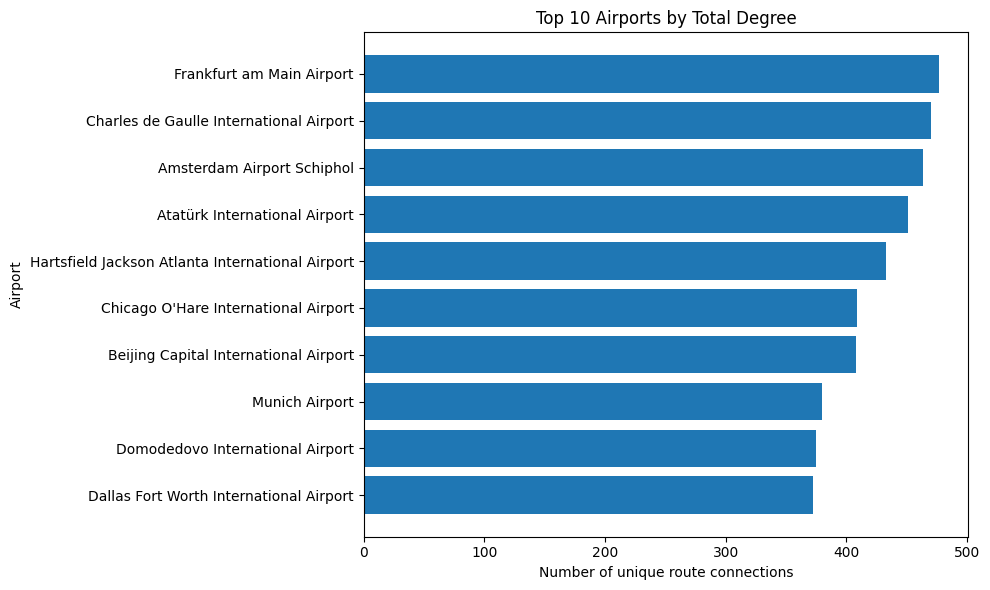

In [14]:
plot_data = top_airports.sort_values('degree')
labels = plot_data['name'] + ' (' + plot_data['iata'].fillna('') + ')' if 'iata' in plot_data else plot_data['name']

plt.figure(figsize=(10, 6))
plt.barh(plot_data['name'], plot_data['degree'], color='#1f77b4')
plt.title('Top 10 Airports by Total Degree')
plt.xlabel('Number of unique route connections')
plt.ylabel('Airport')
plt.tight_layout()
plt.show()

## 3. Degree distribution

A long-tailed distribution indicates that most airports have relatively few direct connections, while a small number serve as highly connected hubs.

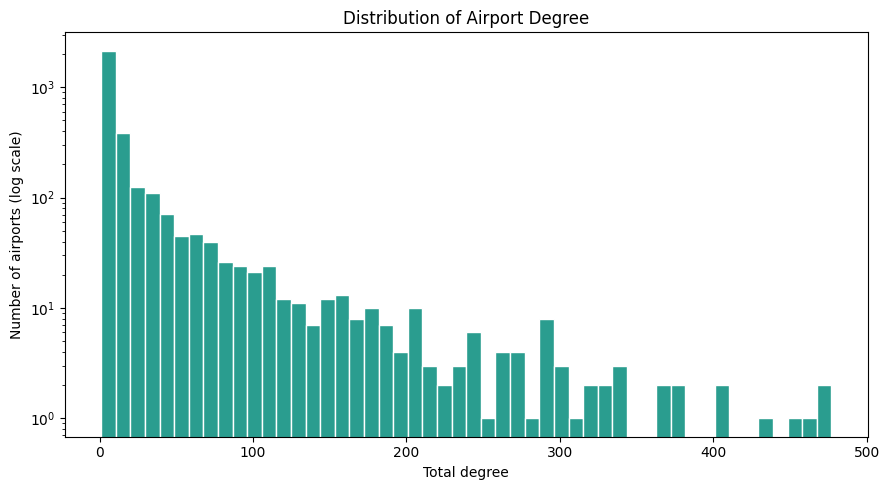

In [15]:
degrees = [degree for _, degree in G.degree()]

plt.figure(figsize=(9, 5))
plt.hist(degrees, bins=50, color='#2a9d8f', edgecolor='white')
plt.yscale('log')
plt.title('Distribution of Airport Degree')
plt.xlabel('Total degree')
plt.ylabel('Number of airports (log scale)')
plt.tight_layout()
plt.show()

## Conclusion

The global airport network is sparse but highly connected through a large dominant component. Its hub structure is clear: a small group of international airports concentrates many direct route connections, while most airports have substantially fewer.